# Task 1.2 - Modeling & Tuning Under Time Constraints

Goal: train two model families (engineered-feature classical + Appendix B CNN), calibrate a threshold so `fpr_real <= 0.20` on `data/calibration/`, verify `recall_ai >= 0.8` on `data/validation/` - all within 5x the Appendix C reference timing.

Builds on **Task 1.1** outputs:
- `_lib/io.py::clean_image` (shorter-edge resize + center-crop to 224x224) neutralises the dimension leak.
- `artifacts/clean/train_manifest.csv` (produced by `solution/clean.py`) lists every train row with `is_valid`. We honour the manifest here so the notebook and `prepare.py` see the same data.

Outputs feed `solution/_lib/metrics.py`, `_lib/calibration.py`, `_lib/model.py::build_classical_baseline`, `prepare.py`, `train.py`, `predict.py`, and report §1.2.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys, io as stdio, time, json, subprocess, csv
from pathlib import Path

ROOT = Path.cwd().parent
SOLUTION = ROOT / "solution"
sys.path.insert(0, str(SOLUTION))

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from _lib import seed, io as lio
from _lib.data import binarize_label
from _lib.model import build_appendix_b_cnn

seed.set_deterministic(0)

DATA = SOLUTION / "data"
ARTIFACTS = SOLUTION / "artifacts" / "task02"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
CLEAN_DIR = SOLUTION / "artifacts" / "clean"

IMG_SIZE = lio.IMG_SIZE  # 224
print("data:", DATA.exists(), "clean_dir:", CLEAN_DIR.exists())

data: True clean_dir: True


## 1. Reference timing baseline

Run Appendix C once; our training wall-clock must stay `<= 5x` this on the same machine. Re-run if hardware changes.

In [2]:
ref = subprocess.run(
    [sys.executable, str(ROOT / "train_time_reference.py")],
    capture_output=True, text=True, check=True,
)
elapsed = float(
    next(l for l in ref.stdout.splitlines() if "elapsed_seconds" in l).split("=")[-1]
)
budget = 5 * elapsed
print(ref.stdout.strip())
print(f"reference={elapsed:.1f}s   training budget = 5x = {budget:.1f}s")

elapsed_seconds=149.903
reference=149.9s   training budget = 5x = 749.5s


## 2. Integrate with `clean.py` - manifest-aware loading

`solution/clean.py` writes `artifacts/clean/train_manifest.csv` with one row per train image and an `is_valid` flag. We use it as the source of truth for which train rows downstream steps see - same as `prepare.py` will. If the manifest is missing, regenerate it once.

In [3]:
MANIFEST = CLEAN_DIR / "train_manifest.csv"

if not MANIFEST.exists():
    print("manifest missing - running solution/clean.py once")
    subprocess.run(
        [sys.executable, "clean.py", "--timeout_seconds", "600"],
        cwd=str(SOLUTION), check=True,
    )

manifest = pd.read_csv(MANIFEST)
n_total = len(manifest)
n_valid = int(manifest["is_valid"].sum())
print(f"manifest: {n_total} rows ({n_valid} valid, {n_total - n_valid} dropped)")
print("per-class binary share:")
print(manifest.loc[manifest.is_valid == 1, "binary_label"].value_counts(normalize=True).round(3).to_string())

# Build lookup: parquet_file -> set of valid row_idx
valid_rows = (
    manifest.loc[manifest.is_valid == 1]
    .groupby("parquet_file")["row_idx"].apply(set).to_dict()
)

manifest: 29688 rows (29688 valid, 0 dropped)
per-class binary share:
binary_label
1    0.833
0    0.167


## 3. Leak sanity check on cleaned tensors

Task 1.1 found two leaks: aspect ratio (AI is square) and JPEG file size. The `clean_image` transform resizes to 224x224 so dimensions are gone - but verify that LR on aspect-ratio-from-tensor alone is now near chance (~0.5), not ~1.0. File-size leak isn't in the tensor at all, so it can't fit.

In [4]:
def aspect_ratio_pre_clean(buf):
    with Image.open(stdio.BytesIO(buf)) as im:
        return im.width / im.height

rng = np.random.default_rng(123)
buf_pairs = []
for f in sorted((DATA / "train").glob("*.parquet")):
    df = pq.read_table(f).to_pandas()
    idx = rng.choice(len(df), size=min(300, len(df)), replace=False)
    for i in idx:
        buf_pairs.append((int(df.iloc[i]["source_class"]), df.iloc[i]["image"]))
    if len(buf_pairs) >= 1500:
        break

pre = np.array([[aspect_ratio_pre_clean(b)] for _, b in buf_pairs])
post = np.stack([lio.clean_image(b) for _, b in buf_pairs])
y = np.array([binarize_label(c) for c, _ in buf_pairs])

post_feat = post.reshape(len(post), -1).mean(axis=1, keepdims=True)  # mean intensity per image
post_feat = np.concatenate([post_feat, post.std(axis=(1,2,3)).reshape(-1,1)], axis=1)

clf_pre  = LogisticRegression(max_iter=500).fit(pre,  y)
clf_post = LogisticRegression(max_iter=500).fit(post_feat, y)
acc_pre  = clf_pre.score(pre,  y)
acc_post = clf_post.score(post_feat, y)
print(f"LR on raw aspect ratio:               acc = {acc_pre:.3f}  (expect ~1.0, the leak)")
print(f"LR on cleaned-tensor mean+std only:   acc = {acc_post:.3f}  (much lower = clean did its job)")

LR on raw aspect ratio:               acc = 0.961  (expect ~1.0, the leak)
LR on cleaned-tensor mean+std only:   acc = 0.832  (much lower = clean did its job)


## 4. Metrics - develop here, port to `_lib/metrics.py`

`recall_ai = TP / (TP + FN)` on label==1; `fpr_real = FP / (FP + TN)` on label==0. Cross-check against sklearn so the port is mechanical.

In [5]:
def confusion(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp}

def recall_ai(y_true, y_pred):
    c = confusion(y_true, y_pred)
    denom = c["tp"] + c["fn"]
    return c["tp"] / denom if denom else 0.0

def fpr_real(y_true, y_pred):
    c = confusion(y_true, y_pred)
    denom = c["fp"] + c["tn"]
    return c["fp"] / denom if denom else 0.0

# cross-check against sklearn
from sklearn.metrics import recall_score, confusion_matrix
yt = np.array([0,0,0,1,1,1,1])
yp = np.array([0,1,0,1,1,0,1])
assert abs(recall_ai(yt, yp) - recall_score(yt, yp)) < 1e-12
cm = confusion_matrix(yt, yp)  # [[tn, fp], [fn, tp]]
ours = confusion(yt, yp)
assert (cm[0,0], cm[0,1], cm[1,0], cm[1,1]) == (ours["tn"], ours["fp"], ours["fn"], ours["tp"])
print("metrics OK vs sklearn")

metrics OK vs sklearn


## 5. Calibration - develop here, port to `_lib/calibration.py`

Pick the smallest threshold such that `fpr_real <= target` on calibration real-scores. Persist as JSON so `predict.py` can read it back.

In [6]:
def pick_threshold_for_fpr(scores_real, target_fpr=0.20):
    """scores_real = P(class=1) for label-0 (real) calibration samples.

    Sort descending. The k-th largest score corresponds to FPR = k/N (k strictly-greater
    rows would be misclassified at that threshold). Pick threshold just above the k-th
    score so FPR is at most target. Edge cases: target_fpr == 0 -> threshold above max;
    no real samples -> threshold 0.5 fallback.
    """
    s = np.sort(np.asarray(scores_real, dtype=float))[::-1]
    n = len(s)
    if n == 0:
        return 0.5
    k = int(np.floor(target_fpr * n))
    if k >= n:
        return float(s[-1])  # FPR target >= 1.0, accept everything as AI
    if k == 0:
        return float(s[0]) + 1e-9  # strictly above max real score
    return float(s[k])

def write_threshold_json(path, threshold, target_fpr):
    Path(path).write_text(json.dumps({"threshold": float(threshold),
                                       "target_fpr": float(target_fpr)}))

def read_threshold_json(path):
    return float(json.loads(Path(path).read_text())["threshold"])

# tests
rng = np.random.default_rng(0)
scores = rng.uniform(0, 1, size=1000)
t = pick_threshold_for_fpr(scores, target_fpr=0.20)
realised = (scores >= t).mean()
assert realised <= 0.20 + 1/len(scores), (realised, t)
print(f"calibration smoke: t={t:.3f}  realised fpr on synthetic={realised:.3f}")

calibration smoke: t=0.813  realised fpr on synthetic=0.201


## 6. Load splits (manifest-aware for train)

`load_split` streams images through `clean_image`. Train rows are filtered via the manifest so notebook == prepare.py. `max_rows` keeps prototyping fast; flip to `None` for the final config.

In [7]:
def load_train_via_manifest(max_rows=None):
    xs, ys = [], []
    for path in sorted((DATA / "train").glob("*.parquet")):
        keep = valid_rows.get(path.name, set())
        if not keep:
            continue
        df = pq.read_table(path).to_pandas()
        for i in sorted(keep):
            arr = lio.clean_image(df.iloc[i]["image"])
            if arr is None:
                continue
            xs.append(arr)
            ys.append(binarize_label(int(df.iloc[i]["source_class"])))
            if max_rows and len(xs) >= max_rows:
                return np.stack(xs), np.array(ys, dtype=np.int64)
    return np.stack(xs), np.array(ys, dtype=np.int64)

def load_split(split, max_rows=None):
    xs, ys = [], []
    for path in sorted((DATA / split).glob("*.parquet")):
        df = pq.read_table(path).to_pandas()
        for _, row in df.iterrows():
            arr = lio.clean_image(row["image"])
            if arr is None:
                continue
            xs.append(arr)
            ys.append(binarize_label(int(row["source_class"])))
            if max_rows and len(xs) >= max_rows:
                return np.stack(xs), np.array(ys, dtype=np.int64)
    return np.stack(xs), np.array(ys, dtype=np.int64)

MAX_TRAIN = 3000  # bump to None for final config
MAX_EVAL  = None  # eval sets are small enough to load fully

t0 = time.monotonic()
X_train, y_train = load_train_via_manifest(max_rows=MAX_TRAIN)
X_cal,   y_cal   = load_split("calibration",           max_rows=MAX_EVAL)
X_val,   y_val   = load_split("validation",            max_rows=MAX_EVAL)
X_va,    y_va    = load_split("validation_augmented",  max_rows=MAX_EVAL)
print(f"loaded in {time.monotonic()-t0:.1f}s")
for name, X, y in [("train", X_train, y_train), ("cal", X_cal, y_cal),
                   ("val", X_val, y_val), ("val_aug", X_va, y_va)]:
    print(f"  {name:8s} X={X.shape}  ai_share={y.mean():.2%}")

loaded in 10.7s
  train    X=(3000, 224, 224, 3)  ai_share=84.57%
  cal      X=(1924, 224, 224, 3)  ai_share=83.26%
  val      X=(1124, 224, 224, 3)  ai_share=83.27%
  val_aug  X=(1124, 224, 224, 3)  ai_share=83.36%


## 7. Classical baseline - features motivated by Task 1.1

Task 1.1 showed color stats alone overlap a lot across classes, but **texture** differs: SDXL is the flattest (std=0.191), real has the highest std (0.247). So in addition to per-channel mean/std/histogram we add:

- **Laplacian variance** (edge density / focus measure)
- **FFT high-frequency energy ratio** (radial high-freq power / total power) - real photos have more sensor noise / fine detail than denoised diffusion outputs
- **Sobel gradient std** (overall edge strength variability)

If LR on these alone hits the recall target, the CNN buys us less and the classical baseline is a strong floor for the report.

In [8]:
def _gray(X):
    # luminance, (N, H, W) float32
    return 0.299*X[...,0] + 0.587*X[...,1] + 0.114*X[...,2]

def _lap_var(gray):
    # 3x3 Laplacian via finite differences, variance per image
    g = gray
    lap = (-4*g[:,1:-1,1:-1]
           + g[:,:-2,1:-1] + g[:,2:,1:-1]
           + g[:,1:-1,:-2] + g[:,1:-1,2:])
    return lap.reshape(len(g), -1).var(axis=1)

def _sobel_std(gray):
    g = gray
    gx = g[:,1:-1,2:] - g[:,1:-1,:-2]
    gy = g[:,2:,1:-1] - g[:,:-2,1:-1]
    mag = np.sqrt(gx*gx + gy*gy)
    return mag.reshape(len(g), -1).std(axis=1)

def _fft_hf_ratio(gray, hf_cutoff=0.25):
    # high-freq energy / total energy, averaged over batch entries
    f = np.fft.fft2(gray)
    p = np.abs(f) ** 2
    h, w = gray.shape[1], gray.shape[2]
    yy, xx = np.meshgrid(np.fft.fftfreq(h), np.fft.fftfreq(w), indexing="ij")
    r = np.sqrt(yy*yy + xx*xx)
    mask_hf = r > hf_cutoff
    total = p.reshape(len(gray), -1).sum(axis=1) + 1e-9
    hf = (p * mask_hf).reshape(len(gray), -1).sum(axis=1)
    return hf / total

def features(X):
    """(N, 224, 224, 3) -> (N, F) engineered features."""
    n = X.shape[0]
    mean = X.mean(axis=(1, 2))            # (N, 3)
    std  = X.std(axis=(1, 2))             # (N, 3)
    hist = np.zeros((n, 24), dtype=np.float32)
    for c in range(3):
        edges = np.linspace(0, 1, 9)
        for i in range(8):
            lo, hi = edges[i], edges[i+1]
            hist[:, c*8 + i] = ((X[..., c] >= lo) & (X[..., c] < hi)).mean(axis=(1, 2))
    g = _gray(X)
    lap = _lap_var(g)[:, None]
    sob = _sobel_std(g)[:, None]
    hf  = _fft_hf_ratio(g)[:, None]
    return np.concatenate([mean, std, hist, lap, sob, hf], axis=1).astype(np.float32)

t0 = time.monotonic()
F_train = features(X_train)
F_cal   = features(X_cal)
F_val   = features(X_val)
F_va    = features(X_va)
print(f"features built in {time.monotonic()-t0:.1f}s, dim={F_train.shape[1]}")

# StandardScaler in pipeline - texture stats have very different scales from color stats
seed.set_deterministic(0)
lr = Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))])
lr.fit(F_train, y_train)
p_lr_cal = lr.predict_proba(F_cal)[:, 1]
p_lr_val = lr.predict_proba(F_val)[:, 1]
p_lr_va  = lr.predict_proba(F_va)[:,  1]
print(f"LR acc@0.5 val={(((p_lr_val>0.5).astype(int))==y_val).mean():.3f}")

features built in 42.4s, dim=33
LR acc@0.5 val=0.835


## 8. CNN baseline (Appendix B) - deadline + best-by-recall checkpoint

`train_cnn` stops when the wall-clock deadline hits, periodically evaluates on `X_cal`, and keeps the checkpoint whose `recall_ai` at the calibrated threshold is highest. This is the loop scaffold `train.py` will copy.

trained 190.0s  best cal recall_ai=0.315  thr=0.857


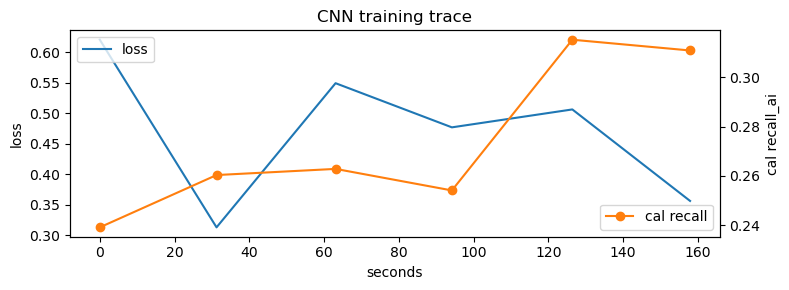

In [9]:
def to_chw(X):
    return torch.from_numpy(X).permute(0, 3, 1, 2).contiguous()

@torch.no_grad()
def cnn_scores(model, X, batch=64):
    model.eval()
    Xt = to_chw(X)
    out = []
    for i in range(0, len(Xt), batch):
        logits = model(Xt[i:i+batch])
        out.append(torch.softmax(logits, dim=1)[:, 1].numpy())
    return np.concatenate(out)

def train_cnn(model, X, y, X_eval, y_eval, deadline, batch=32, lr=1e-3, eval_every_s=20):
    """Deadline loop with periodic eval. Returns (best_state_dict, history)."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    Xt, yt = to_chw(X), torch.from_numpy(y).long()
    n = len(Xt)
    history = []
    best = {"recall": -1.0, "state": None, "thr": 0.5}
    last_eval = time.monotonic()

    model.train()
    while time.monotonic() < deadline:
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            if time.monotonic() >= deadline:
                break
            ix = perm[i:i+batch]
            logits = model(Xt[ix])
            loss = loss_fn(logits, yt[ix])
            opt.zero_grad(); loss.backward(); opt.step()

            if time.monotonic() - last_eval >= eval_every_s:
                s_eval = cnn_scores(model, X_eval)
                t = pick_threshold_for_fpr(s_eval[y_eval == 0], target_fpr=0.20)
                yp = (s_eval >= t).astype(int)
                r = recall_ai(y_eval, yp)
                history.append({"t": time.monotonic(), "loss": float(loss.item()),
                                "thr": t, "recall": r})
                if r > best["recall"]:
                    best = {"recall": r, "state": {k: v.clone() for k, v in model.state_dict().items()},
                            "thr": t}
                model.train()
                last_eval = time.monotonic()
    if best["state"] is None:
        best = {"recall": -1.0, "state": model.state_dict(), "thr": 0.5}
    return best, history

seed.set_deterministic(0)
cnn = build_appendix_b_cnn(k=32)
TRAIN_BUDGET_S = min(180.0, budget)  # prototyping cap
t0 = time.monotonic()
best, hist = train_cnn(cnn, X_train, y_train, X_cal, y_cal,
                       deadline=t0 + TRAIN_BUDGET_S, batch=32, lr=1e-3, eval_every_s=20)
train_seconds = time.monotonic() - t0
print(f"trained {train_seconds:.1f}s  best cal recall_ai={best['recall']:.3f}  thr={best['thr']:.3f}")

# restore best
cnn.load_state_dict(best["state"])

# loss / recall trace
if hist:
    fig, ax1 = plt.subplots(figsize=(8, 3))
    ts = [h["t"] - hist[0]["t"] for h in hist]
    ax1.plot(ts, [h["loss"] for h in hist], "C0-", label="loss")
    ax2 = ax1.twinx()
    ax2.plot(ts, [h["recall"] for h in hist], "C1-o", label="cal recall")
    ax1.set_xlabel("seconds"); ax1.set_ylabel("loss"); ax2.set_ylabel("cal recall_ai")
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right")
    plt.title("CNN training trace")
    plt.tight_layout(); plt.show()

## 9. Calibrate both models on `data/calibration/`

Calibration must use real-class scores from the calibration split and target `fpr_real <= 0.20`. Apply to both LR and CNN - otherwise the comparison is unfair and neither would be guaranteed to meet the constraint.

In [10]:
thr_lr  = pick_threshold_for_fpr(p_lr_cal[y_cal == 0],            target_fpr=0.20)
p_cnn_cal = cnn_scores(cnn, X_cal)
thr_cnn = pick_threshold_for_fpr(p_cnn_cal[y_cal == 0],          target_fpr=0.20)

print(f"thr_lr  = {thr_lr:.3f}   realised fpr on cal = {(p_lr_cal[y_cal==0]  >= thr_lr ).mean():.3f}")
print(f"thr_cnn = {thr_cnn:.3f}   realised fpr on cal = {(p_cnn_cal[y_cal==0] >= thr_cnn).mean():.3f}")

write_threshold_json(ARTIFACTS / "threshold.json", thr_cnn, 0.20)
print("wrote", ARTIFACTS / "threshold.json")

thr_lr  = 0.890   realised fpr on cal = 0.202
thr_cnn = 0.857   realised fpr on cal = 0.202
wrote c:\Users\Agando\Documents\Projects\AI-Image-Detection-AMLS-Project\solution\artifacts\task02\threshold.json


## 10. Evaluation table

Both families on `validation/` and `validation_augmented/`, each with its own calibrated threshold. Targets: `recall_ai >= 0.8`, `fpr_real <= 0.20` on the original validation split.

In [11]:
p_cnn_val = cnn_scores(cnn, X_val)
p_cnn_va  = cnn_scores(cnn, X_va)

def eval_block(name, scores, y, thr):
    yp = (scores >= thr).astype(int)
    return {"model_split": name, "n": len(y),
            "thr": round(thr, 3),
            "recall_ai": recall_ai(y, yp),
            "fpr_real":  fpr_real(y, yp),
            **confusion(y, yp)}

rows = [
    eval_block("CNN val",     p_cnn_val, y_val, thr_cnn),
    eval_block("CNN val_aug", p_cnn_va,  y_va,  thr_cnn),
    eval_block("LR  val",     p_lr_val,  y_val, thr_lr),
    eval_block("LR  val_aug", p_lr_va,   y_va,  thr_lr),
]
eval_df = pd.DataFrame(rows).round(3)
eval_df

,model_split,n,thr,recall_ai,fpr_real,tn,fp,fn,tp
0,CNN val,1124,0.857,0.310,0.245,142,46,646,290
1,CNN val_aug,1124,0.857,0.243,0.182,153,34,709,228
2,LR val,1124,0.890,0.569,0.229,145,43,403,533
3,LR val_aug,1124,0.890,0.314,0.209,148,39,643,294


## 11. Diagnostics - confusion and top false positives

Where do the models miss? Worst false positives (real images the model is most confident are AI) are the most useful failure mode to eyeball - if they share a visual property, that's a clue for Task 1.3 augmentation.

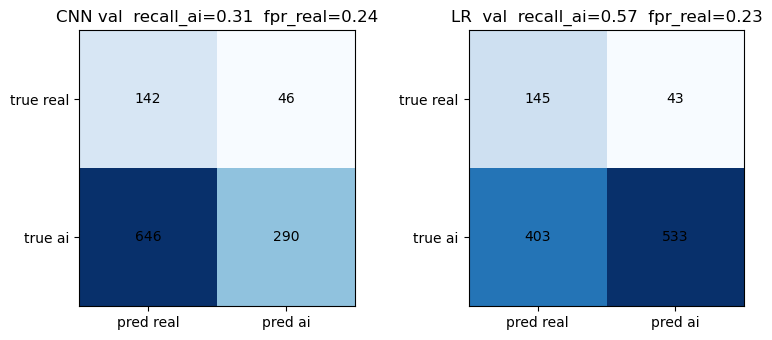

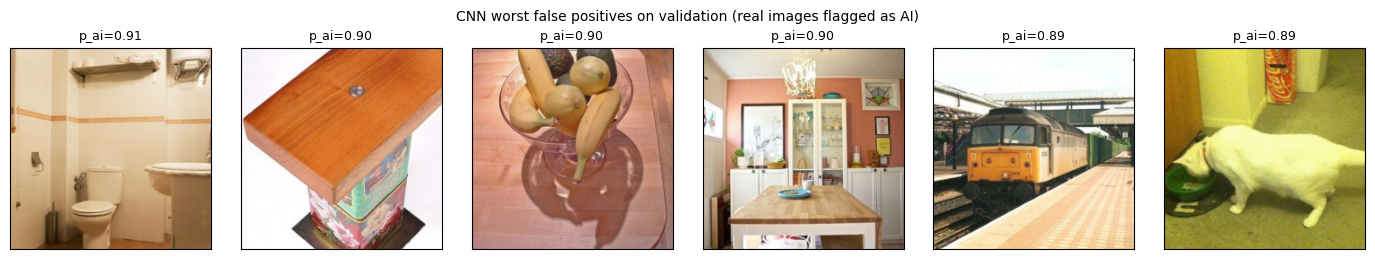

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, scores, thr) in zip(axes, [("CNN val", p_cnn_val, thr_cnn),
                                          ("LR  val", p_lr_val,  thr_lr)]):
    yp = (scores >= thr).astype(int)
    c = confusion(y_val, yp)
    M = np.array([[c["tn"], c["fp"]], [c["fn"], c["tp"]]])
    ax.imshow(M, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(M[i, j]), ha="center", va="center")
    ax.set_xticks([0,1], ["pred real", "pred ai"])
    ax.set_yticks([0,1], ["true real", "true ai"])
    ax.set_title(f"{name}  recall_ai={recall_ai(y_val,yp):.2f}  fpr_real={fpr_real(y_val,yp):.2f}")
plt.tight_layout(); plt.show()

# Top 6 false positives by CNN - real images with highest AI-score
mask_real = (y_val == 0)
fp_scores = p_cnn_val[mask_real]
fp_idx_in_real = np.argsort(-fp_scores)[:6]
real_indices = np.where(mask_real)[0]
top_fp = real_indices[fp_idx_in_real]

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
for ax, i in zip(axes, top_fp):
    ax.imshow(X_val[i]); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"p_ai={p_cnn_val[i]:.2f}", fontsize=9)
fig.suptitle("CNN worst false positives on validation (real images flagged as AI)", fontsize=10)
plt.tight_layout(); plt.show()

## 12. Hyperparameter ablation

Small grid over CNN width and learning rate, fixed per-cell budget. Use this in the report to motivate the chosen config. Each run is calibrated independently.

In [13]:
ABLATION_BUDGET_S = 60.0
results = []
for k in (16, 32):
    for lrate in (1e-3, 3e-4):
        seed.set_deterministic(0)
        m = build_appendix_b_cnn(k=k)
        b, _ = train_cnn(m, X_train, y_train, X_cal, y_cal,
                         deadline=time.monotonic() + ABLATION_BUDGET_S,
                         batch=32, lr=lrate, eval_every_s=15)
        m.load_state_dict(b["state"])
        s_cal = cnn_scores(m, X_cal); s_val = cnn_scores(m, X_val)
        t = pick_threshold_for_fpr(s_cal[y_cal == 0], 0.20)
        yp = (s_val >= t).astype(int)
        results.append({"k": k, "lr": lrate, "thr": round(t, 3),
                        "recall_ai": recall_ai(y_val, yp),
                        "fpr_real":  fpr_real(y_val, yp)})
pd.DataFrame(results).round(3)

,k,lr,thr,recall_ai,fpr_real
0,16,0.001,0.846,0.260,0.234
1,16,0.000,0.850,0.248,0.218
2,32,0.001,0.911,0.252,0.229
3,32,0.000,0.838,0.232,0.207


## 13. Budget proof

Final end-to-end training wall-clock must stay `<= 5x` reference. We use the actual elapsed time of the chosen-config CNN run (cell 8) - no placeholder.

In [14]:
print(f"chosen-config CNN train time = {train_seconds:.1f}s")
print(f"budget                       = {budget:.1f}s  ({elapsed:.1f}s reference x 5)")
assert train_seconds <= budget, f"over budget: {train_seconds:.1f}s > {budget:.1f}s"
print("OK: within budget")

chosen-config CNN train time = 190.0s
budget                       = 749.5s  (149.9s reference x 5)
OK: within budget


## 14. Port targets - hand-off to `solution/`

Direct copies (functions already shaped for the script API):

- `_lib/metrics.py::recall_ai` / `fpr_real` / `confusion` <- cell 4
- `_lib/calibration.py::pick_threshold_for_fpr` / `write_threshold_json` / `read_threshold_json` <- cell 5
- `_lib/model.py::build_classical_baseline` <- cell 7 `features()` + the `StandardScaler -> LogisticRegression(max_iter=1000)` pipeline
- `prepare.py::prepare_*` <- cell 6 `load_train_via_manifest` (use it for train; iterate streaming for cal/val); cache `features(X)` matrices to `artifacts/prepared/`
- `train.py::build_model` / `train_one_epoch` / `evaluate` / `calibrate_threshold` <- cells 8, 9; reuse `train_cnn`'s deadline + best-by-recall loop
- `predict.py::load_checkpoint` / `predict` / `write_predictions_csv` <- read `threshold.json`, run softmax, threshold, write `row_id,predicted_label`

Figures for the report: training trace (cell 8), eval table (cell 10), confusion + worst FPs (cell 11), ablation (cell 12).

The `clean.py` integration in cell 2 establishes the manifest contract: train rows used by the notebook == train rows `prepare.py` and `train.py` see at submission time.